In [4]:
import pandas as pd
import numpy as np
import joblib
import json
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Bidirectional, LSTM, GRU, Dense, Dropout
from tensorflow.keras.optimizers import Adam

df = pd.read_csv("C:\\Users\\prane\\OneDrive\\Desktop\\dos_normal_extracted.csv")
print("Loaded data.")
print("Columns:", df.columns.tolist())
print(df.head(3))

features = ['smean', 'rate', 'sttl', 'sinpkt', 'synack', 'ackdat']

X = df[features].copy()
y = df['label'].astype(int)
scaler = MinMaxScaler().fit(X)
X_scaled = scaler.transform(X)


joblib.dump(scaler, 'scaler.pkl')
print(" Saved scaler.")

with open('features.json', 'w') as f:
    json.dump(features, f)
print("Saved feature names.")
X_tr, X_te, y_tr, y_te = train_test_split(
    X_scaled, y, 
    test_size=0.2, 
    random_state=42,
    stratify=y
)

X_tr = X_tr.reshape((-1, 1, X_tr.shape[1]))  # (samples, timesteps, features)
X_te = X_te.reshape((-1, 1, X_te.shape[1]))

model = Sequential([
    Bidirectional(LSTM(64, return_sequences=True), input_shape=(1, X_tr.shape[2])),
    GRU(32),
    Dropout(0.3),
    Dense(16, activation='relu'),
    Dense(1, activation='sigmoid')   # binary classification
])
model.compile(
    optimizer=Adam(1e-3),
    loss='binary_crossentropy',
    metrics=['accuracy']
)
model.summary()
history = model.fit(
    X_tr, y_tr,
    validation_data=(X_te, y_te),
    epochs=20,
    batch_size=64
)

model.save('ddos_bilstm_gru.h5')
print("✅ Model trained and saved!")




Loaded data.
Columns: ['id', 'dur', 'proto', 'service', 'state', 'spkts', 'dpkts', 'sbytes', 'dbytes', 'rate', 'sttl', 'dttl', 'sload', 'dload', 'sloss', 'dloss', 'sinpkt', 'dinpkt', 'sjit', 'djit', 'swin', 'stcpb', 'dtcpb', 'dwin', 'tcprtt', 'synack', 'ackdat', 'smean', 'dmean', 'trans_depth', 'response_body_len', 'ct_srv_src', 'ct_state_ttl', 'ct_dst_ltm', 'ct_src_dport_ltm', 'ct_dst_sport_ltm', 'ct_dst_src_ltm', 'is_ftp_login', 'ct_ftp_cmd', 'ct_flw_http_mthd', 'ct_src_ltm', 'ct_srv_dst', 'is_sm_ips_ports', 'attack_cat', 'label']
    id       dur proto service state  spkts  dpkts  sbytes  dbytes       rate  \
0  247  0.921987  ospf       -   INT     20      0    1280       0  20.607666   
1  288  1.173262   tcp       -   FIN     16     12    2080    1746  23.012763   
2  337  1.438237   tcp    http   FIN     10     10     958    2726  13.210619   

   ...  ct_dst_sport_ltm  ct_dst_src_ltm  is_ftp_login  ct_ftp_cmd  \
0  ...                 1               2             0           0

C:\Users\prane\anaconda3\envs\ddos_env\lib\site-packages\keras\src\layers\rnn\bidirectional.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ bidirectional_2 (Bidirectional)      │ (None, 1, 128)              │          36,352 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ gru_2 (GRU)                          │ (None, 32)                  │          15,552 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ (None, 32)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_4 (Dense)                      │ (None, 16)                  │             528 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_5 (Dense)                      │ (None, 1)                   │              17 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 52,449 (204.88 KB)

 Trainable params: 52,449 (204.88 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
409/409 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - accuracy: 0.7683 - loss: 0.5324 - val_accuracy: 0.8312 - val_loss: 0.4167
Epoch 2/20
409/409 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.8518 - loss: 0.3987 - val_accuracy: 0.8522 - val_loss: 0.3721
Epoch 3/20
409/409 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.8511 - loss: 0.3710 - val_accuracy: 0.8536 - val_loss: 0.3474
Epoch 4/20
409/409 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.8560 - loss: 0.3407 - val_accuracy: 0.8730 - val_loss: 0.3105
Epoch 5/20
409/409 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.8770 - loss: 0.3031 - val_accuracy: 0.8829 - val_loss: 0.2958
Epoch 6/20
409/409 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.8781 - loss: 0.3025 - val_accuracy: 0.8870 - val_loss: 0.2939
Epoch 7/20
409/409 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.8820 - loss: 0.2928 - val_accuracy: 0.8812 - val_loss: 0.2909
Epoch 8/20
409/409 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.8797 - loss: 0.2956 - val_accuracy: 0.

✅ Model trained and saved!


205/205 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step    

✅ Classification Report:

              precision    recall  f1-score   support

           0       0.89      0.95      0.92      3271
           1       0.94      0.88      0.91      3271

    accuracy                           0.91      6542
   macro avg       0.92      0.91      0.91      6542
weighted avg       0.92      0.91      0.91      6542


✅ Confusion Matrix:
[[3099  172]
 [ 388 2883]]


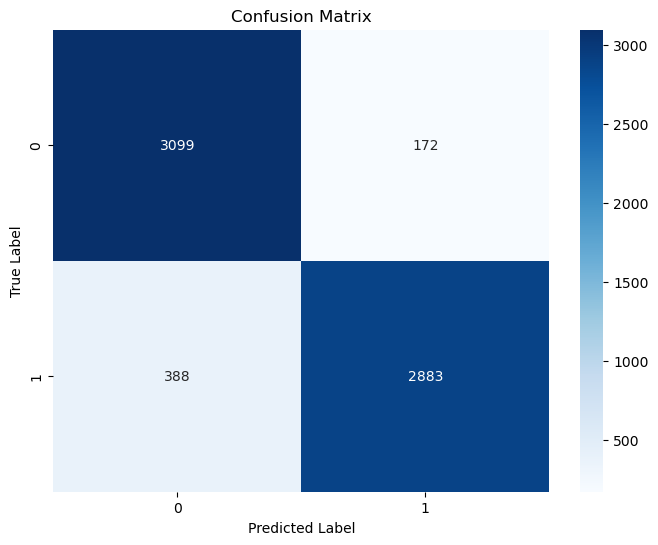


Overall Accuracy: 91.44%


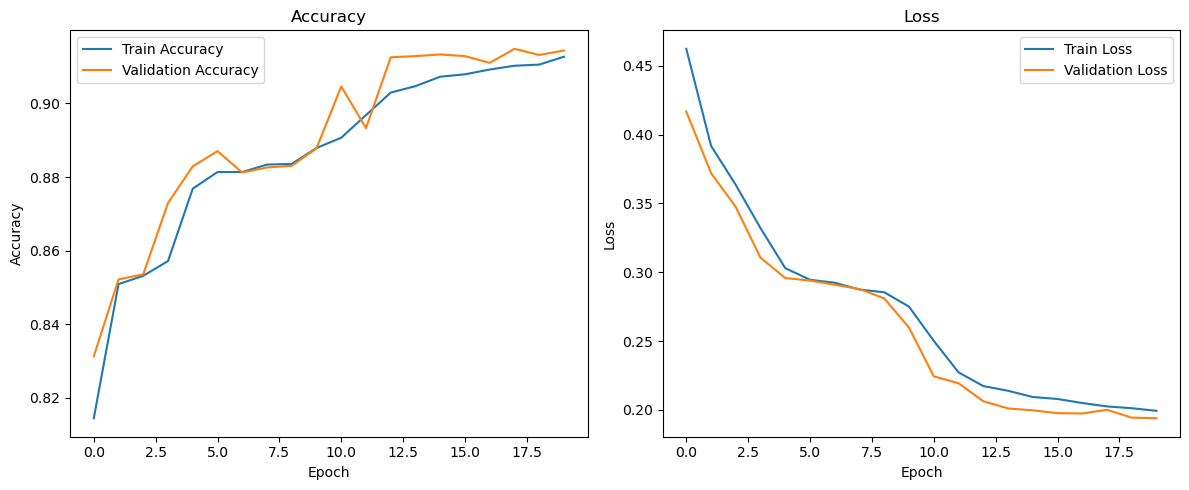

In [5]:
y_pred_probs = model.predict(X_te)
y_pred = (y_pred_probs > 0.5).astype(int).flatten()


print("\n✅ Classification Report:\n")
print(classification_report(y_te, y_pred))

cm = confusion_matrix(y_te, y_pred)
print("\n✅ Confusion Matrix:")
print(cm)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()

acc = accuracy_score(y_te, y_pred)
print(f"\nOverall Accuracy: {acc*100:.2f}%")

plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()
